In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sys.path.append(str(Path('../utils').resolve()))

from funciones_eda import cardinalidad, plot_categorical_relationship_fin, pinta_distribucion_categoricas, plot_combined_graphs

In [3]:
agrupacion_horas = pd.read_csv("../data/agrupacion_horas.csv", sep= None, engine='python')
cierre_caja = pd.read_csv("../data/cierre_caja.csv", sep= None, engine='python')
compras_articulos = pd.read_csv("../data/compras_articulos.csv", sep= None, engine='python')
compras_tpv = pd.read_csv("../data/compras_tpv.csv", sep= None, engine='python')
ventas_glovo = pd.read_csv("../data/ventas_glovo.csv", sep= None, engine='python')

In [4]:
cierre_caja.columns = cierre_caja.columns.str.replace('\ufeff', '', regex=False).str.strip()
compras_tpv.columns = compras_tpv.columns.str.replace('\ufeff', '', regex=False).str.strip()
ventas_glovo.columns = ventas_glovo.columns.str.replace('\ufeff', '', regex=False).str.strip()

In [5]:
agrupacion_horas

,DateType,NoOfTrans,RefundQty,RefundValue,NoSaleQty,VoidLineQty,VoidLineValue,ItemQty,Value,Discount,AvgValueIncVAT,ValueIncVAT,ValueExcVAT,AvgMargin,Margin,MarginPerc
0,00:00-00:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
1,01:00-01:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
2,02:00-02:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
3,03:00-03:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
4,04:00-04:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
5,05:00-05:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
6,06:00-06:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
7,07:00-07:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
8,08:00-08:59,0,0,0.00,0,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000
9,09:00-09:59,88,1,0.15,0,74,144.92,483,245.02,2.20,2.76,242.82,214.22,1.45,127.64,0.5958


In [6]:
cierre_caja.head(5)

,Date,NoOfTrans,RefundQty,RefundValue,NoSaleQty,VoidLineQty,VoidLineValue,ItemQty,Value,Discount,AvgValueIncVAT,ValueIncVAT,ValueExcVAT,AvgMargin,Margin,MarginPerc
0,08/05/2026 5:00:00,46,0,0.00,0,88,202.78,381,400.11,1.26,8.67,398.85,331.35,2.53,116.47,0.3515
1,07/05/2026 5:00:00,36,0,0.00,0,119,181.65,443,410.72,0.00,11.41,410.72,339.40,3.14,113.08,0.3332
2,06/05/2026 5:00:00,42,121,19.81,0,132,112.33,352,168.13,0.00,4.00,168.13,138.89,1.95,81.69,0.5882
3,05/05/2026 5:00:00,44,0,0.00,0,17,38.04,284,287.49,-1.70,6.57,289.19,239.62,2.68,118.13,0.4930
4,04/05/2026 5:00:00,50,6,1.00,0,26,11.30,455,266.88,-1.30,5.36,268.18,223.01,2.65,132.71,0.5951


In [7]:
compras_articulos.head(20)

,ProductID,Name,Description,OrderCode,Brand,Size,Qty,Value,Discount,ValueIncVAT,ValueExcVAT,TotCost,Margin,MarginPerc
0,2160051,Doble Cara A4 Color,Doble Cara A4 Color,NaN,NaN,NaN,513,410.40,14.74,395.66,360.60,25.65,334.95,0.92887
1,2156338,10 Colores Mickey,10 Colores Mickey,NaN,NaN,NaN,1,5.89,0.00,5.89,4.87,3.46,1.41,0.28953
2,2154194,1200 Amarillo C-005,1200 Amarillo C-005,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
3,2154182,1200 Azul C-010,1200 Azul C-010,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
4,2154202,1200 Naranja Fluo C-066,1200 Naranja Fluo C-066,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
5,2154208,1200 Oro C-053,1200 Oro C-053,NaN,NaN,NaN,1,1.95,0.00,1.95,1.61,1.00,0.61,0.37888
6,2154178,1200 Rojo C-002,1200 Rojo C-002,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
7,2154207,1200 Verde Fluo C-011,1200 Verde Fluo C-011,NaN,NaN,NaN,3,3.60,0.00,3.60,2.97,1.38,1.59,0.53535
8,2154185,1200 Verde Oscuro C-004,1200 Verde Oscuro C-004,NaN,NaN,NaN,2,2.40,0.00,2.40,1.98,0.92,1.06,0.53535
9,2160065,1ª Página,1ª Página,NaN,NaN,NaN,167,167.00,0.05,166.95,156.74,8.35,148.39,0.94673


In [8]:
compras_tpv.head(20)

,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Motivo del Descuento,Ventas NETAS,Comida para consumir en el Lugar o para Llevar,Opción de Comer,Código Fiscal,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,Nominal,A/C Ref,Notas,Identificación del Cliente,ProductId
0,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:57:01,0.00,NaN,1.24,Eat in,0,NaN,0.26,1.50,1.0071,0.2329,Efectivo,NaN,NaN,NaN,NaN,2336673
1,Panini Cromos Mundial 2026,5.0,Otros,08/05/2026 19:54:52,0.00,NaN,6.20,Eat in,0,NaN,1.30,7.50,5.0355,1.1645,Tarjeta,NaN,NaN,NaN,NaN,2336673
2,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.00,NaN,0.58,Eat in,0,NaN,0.12,0.70,0.1800,0.4000,Efectivo,NaN,NaN,NaN,NaN,2155714
3,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.00,NaN,0.58,Eat in,0,NaN,0.12,0.70,0.1800,0.4000,Efectivo,NaN,NaN,NaN,NaN,2155714
4,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:26:40,0.00,NaN,1.24,Eat in,0,NaN,0.26,1.50,1.0071,0.2329,Efectivo,NaN,NaN,NaN,NaN,2336673
5,Copia A4 Color,5.0,Copisteria,08/05/2026 19:26:40,0.00,NaN,1.86,Eat in,0,NaN,0.39,2.25,0.2500,1.6100,Efectivo,NaN,NaN,NaN,NaN,2160049
6,Panini Cromos Mundial 2026,10.0,Otros,08/05/2026 18:52:20,0.00,NaN,12.40,Eat in,0,NaN,2.60,15.00,10.0710,2.3290,Tarjeta,NaN,NaN,NaN,NaN,2336673
7,Panini Album Mundial 2026,1.0,Otros,08/05/2026 18:52:20,0.00,NaN,4.13,Eat in,0,NaN,0.87,5.00,3.3570,0.7730,Tarjeta,NaN,NaN,NaN,NaN,2336677
8,Etiqueta Color,1.0,Copisteria,08/05/2026 18:47:29,0.00,NaN,0.54,Eat in,0,NaN,0.11,0.65,0.0500,0.4900,Tarjeta,NaN,NaN,NaN,NaN,2160063
9,Etiqueta Color,1.0,Copisteria,08/05/2026 18:47:29,0.00,NaN,0.54,Eat in,0,NaN,0.11,0.65,0.0500,0.4900,Tarjeta,NaN,NaN,NaN,NaN,2160063


In [9]:
ventas_glovo.head(5)

,Name,Description,Category,Price,Qty,SalesIncVAT,Discount,NetIncVAT,NetExcVAT,TotalCost,Margin,MarginPercent
0,5 Boligrafos Bic Cristal,5 Boligrafos Bic Cristal,BIC,0.00,3,0.00,-6.75,6.75,6.75,8.25,-1.50,-0.2222
1,5 Boligrafos Bic Cristal Medium,5 Boligrafos Bic Cristal Medium,BIC,2.25,1,2.25,0.00,2.25,1.86,0.00,1.86,1.0000
2,Afilador Faber-Castell deposito trans,Afilador Faber-Castell deposito trans,Afilador,2.00,2,4.00,0.00,4.00,3.31,0.94,2.37,0.7160
3,Bloc Cartulina Praxton,Bloc Cartulina Praxton,Blocs,4.00,9,36.00,0.00,36.00,29.79,5.22,24.57,0.8248
4,Bloc de Charol Praxton 10H,Bloc de Charol Praxton 10H,Blocs,2.30,6,13.80,0.00,13.80,11.40,2.10,9.30,0.8158


## Dataset: `agrupacion_horas.csv`
**Descripción:** Ventas por agrupación de horas  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| DateType          | Franja horaria del día                           | Categórica           | Formato HH:00-HH:59, 24 franjas (00h a 23h)       |
| NoOfTrans         | Número de transacciones realizadas               | Numérica Discreta    | 0 en horas sin actividad                           |
| RefundQty         | Cantidad de unidades devueltas                   | Numérica Discreta    | Máximo 125 uds en una franja                       |
| RefundValue       | Valor económico de las devoluciones (€)          | Numérica Continua    | Máximo 47.70€                                      |
| NoSaleQty         | Aperturas de caja sin venta                      | Numérica Discreta    | Casi siempre 0                                     |
| VoidLineQty       | Cantidad de líneas de venta anuladas             | Numérica Discreta    | Máximo 797                                         |
| VoidLineValue     | Valor de las líneas anuladas (€)                 | Numérica Continua    | Máximo 929.06€                                     |
| ItemQty           | Total de artículos vendidos                      | Numérica Discreta    | Máximo 4.402 uds en una franja                     |
| Value             | Ventas brutas antes de IVA (€)                   | Numérica Continua    | Máximo 3.339€                                      |
| Discount          | Descuentos aplicados (€)                         | Numérica Continua    | Puede ser negativo                                 |
| AvgValueIncVAT    | Ticket medio por transacción con IVA (€)         | Numérica Continua    | Máximo 8.76€                                       |
| ValueIncVAT       | Ventas totales con IVA (€)                       | Numérica Continua    | Máximo 3.280€                                      |
| ValueExcVAT       | Ventas totales sin IVA (€)                       | Numérica Continua    | Máximo 2.821€                                      |
| AvgMargin         | Margen medio por transacción (€)                 | Numérica Continua    | Máximo 4.85€                                       |
| Margin            | Margen bruto total de la franja (€)              | Numérica Continua    | Máximo 1.524€                                      |
| MarginPerc        | Porcentaje de margen sobre ventas                | Numérica Continua    | Valores entre 0 y 0.63 (0–63%)                     |

## Dataset: `cierre_caja.csv`
**Descripción:** El total de ventas por dias  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Date              | Fecha del cierre de caja                         | Fecha                | Formato DD/MM/YYYY, 94 días de datos               |
| NoOfTrans         | Número de transacciones del día                  | Numérica Discreta    | Media 37, máximo 66                                |
| RefundQty         | Unidades devueltas en el día                     | Numérica Discreta    | Máximo 121 uds en un día                           |
| RefundValue       | Valor económico de las devoluciones (€)          | Numérica Continua    | Máximo 31.35€                                      |
| NoSaleQty         | Aperturas de caja sin venta                      | Numérica Discreta    | Casi siempre 0                                     |
| VoidLineQty       | Líneas de venta anuladas en el día               | Numérica Discreta    | Máximo 280                                         |
| VoidLineValue     | Valor de las líneas anuladas (€)                 | Numérica Continua    | Máximo 202.78€                                     |
| ItemQty           | Total de artículos vendidos en el día            | Numérica Discreta    | Media 275, máximo 1.016                            |
| Value             | Ventas brutas del día (€)                        | Numérica Continua    | Media 182.9€, máximo 410.72€                       |
| Discount          | Descuentos aplicados en el día (€)               | Numérica Continua    | Puede ser negativo                                 |
| AvgValueIncVAT    | Ticket medio por transacción con IVA (€)         | Numérica Continua    | Media 4.73€, máximo 12.85€                         |
| ValueIncVAT       | Ventas totales del día con IVA (€)               | Numérica Continua    | Media 181.3€, máximo 410.72€                       |
| ValueExcVAT       | Ventas totales del día sin IVA (€)               | Numérica Continua    | Media 156.8€, máximo 339.40€                       |
| AvgMargin         | Margen medio por transacción (€)                 | Numérica Continua    | Media 2.29€, máximo 8.76€                          |
| Margin            | Margen bruto total del día (€)                   | Numérica Continua    | Media 87.7€, máximo 211.11€                        |
| MarginPerc        | Porcentaje de margen sobre ventas                | Numérica Continua    | Media 53.2%, máximo 75.6%                          |

## Dataset: `compras_articulos.csv`
**Descripción:** Catálogo de artículos vendidos con sus costes, ventas y márgenes por producto  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| ProductID         | Identificador único del producto                 | Categórica           | Clave primaria del artículo                        |
| Name              | Nombre del producto                              | Categórica           | 862 artículos distintos                            |
| Description       | Descripción del producto                         | Categórica           | 14 valores nulos                                   |
| OrderCode         | Código de pedido del proveedor                   | Categórica           | Casi siempre nulo                                  |
| Brand             | Marca del producto                               | Categórica           | Mayoritariamente nulo                              |
| Size              | Tamaño del producto                              | Numérica Continua    | Todo nulo, columna sin datos útiles                |
| Qty               | Unidades vendidas del artículo                   | Numérica Discreta    | Media 30, máximo 8.553                             |
| Value             | Ventas brutas del artículo (€)                   | Numérica Continua    | Media 19.9€, máximo 1.525€                         |
| Discount          | Descuentos aplicados (€)                         | Numérica Continua    | Puede ser negativo                                 |
| ValueIncVAT       | Ventas con IVA (€)                               | Numérica Continua    | Media 19.8€, máximo 1.510€                         |
| ValueExcVAT       | Ventas sin IVA (€)                               | Numérica Continua    | Media 17.1€, máximo 1.400€                         |
| TotCost           | Coste total del artículo (€)                     | Numérica Continua    | Media 7.5€, máximo 427.65€                         |
| Margin            | Margen bruto del artículo (€)                    | Numérica Continua    | Puede ser negativo, máximo 1.095€                  |
| MarginPerc        | Porcentaje de margen sobre ventas                | Numérica Continua    | Media 45.7%, máximo 100%                           |

## Dataset: `compras_tpv.csv`
**Descripción:** Líneas de venta individuales registradas en el TPV con detalle de producto, categoría y método de pago  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo                              | Descripción                                      | Tipo de variable     | Notas                                              |
|-----------------------------------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Producto                                      | Nombre del producto vendido                      | Categórica           | 7.615 líneas de venta                              |
| Cantidad                                      | Unidades vendidas en la línea                    | Numérica Continua    | Puede ser negativo (devoluciones)                  |
| Categoría                                     | Categoría del producto                           | Categórica           | 302 valores nulos                                  |
| Fecha/Hora                                    | Fecha y hora de la transacción                   | Fecha                | Formato DD/MM/YYYY HH:MM:SS                        |
| Valor del Descuento                           | Descuento aplicado en la línea (€)               | Numérica Continua    | Puede ser negativo                                 |
| Motivo del Descuento                          | Razón del descuento aplicado                     | Categórica           | 7.469 valores nulos (casi siempre vacío)           |
| Ventas NETAS                                  | Importe neto de la venta (€)                     | Numérica Continua    | Media 1.94€, máximo 123.97€                        |
| Comida para consumir en el Lugar o para Llevar| Indica si es para consumir o llevar              | Categórica           | Valores: Eat in / Take away                        |
| Opción de Comer                               | Código numérico de la opción de comer            | Numérica Discreta    | Casi siempre 0                                     |
| Código Fiscal                                 | Código fiscal de la transacción                  | Numérica Continua    | Todo nulo, sin datos útiles                        |
| Impuesto                                      | IVA aplicado en la línea (€)                     | Numérica Continua    | Media 0.30€                                        |
| Ventas TOTALES                                | Importe total con IVA (€)                        | Numérica Continua    | Media 2.24€, máximo 150€                           |
| Precio de Coste                               | Coste del producto (€)                           | Numérica Continua    | Media 0.85€, máximo 100.71€                        |
| Margen                                        | Margen bruto de la línea (€)                     | Numérica Continua    | Media 1.08€, puede ser negativo                    |
| Método de Pago                                | Canal de pago utilizado                          | Categórica           | Tarjeta, Efectivo, Credit, Glovo, Mixto            |
| Nominal                                       | Valor nominal                                    | Numérica Continua    | Todo nulo, sin datos útiles                        |
| A/C Ref                                       | Referencia de cuenta                             | Numérica Continua    | Todo nulo, sin datos útiles                        |
| Notas                                         | Notas adicionales de la transacción              | Categórica           | Casi siempre nulo                                  |
| Identificación del Cliente                    | ID del cliente                                   | Numérica Continua    | 7.240 valores nulos                                |
| ProductId                                     | Identificador único del producto                 | Numérica Discreta    | Clave para cruzar con compras_articulos            |

## Dataset: `ventas_glovo.csv`
**Descripción:** Ventas realizadas a través del canal Glovo con detalle de producto, precio y margen  
**Periodo:** 1 de enero – 8 de mayo de 2026

| Nombre del campo  | Descripción                                      | Tipo de variable     | Notas                                              |
|-------------------|--------------------------------------------------|----------------------|----------------------------------------------------|
| Name              | Nombre del producto                              | Categórica           | 59 productos distintos en Glovo                    |
| Description       | Descripción del producto                         | Categórica           | 1 valor nulo                                       |
| Category          | Categoría del producto                           | Categórica           | Categorías propias de Glovo                        |
| Price             | Precio de venta unitario (€)                     | Numérica Continua    | Media 4.30€, máximo 15.45€                         |
| Qty               | Unidades vendidas                                | Numérica Discreta    | Media 2.4, máximo 9                                |
| SalesIncVAT       | Ventas totales con IVA (€)                       | Numérica Continua    | Media 11.4€, máximo 63.35€                         |
| Discount          | Descuentos aplicados (€)                         | Numérica Continua    | Puede ser negativo                                 |
| NetIncVAT         | Ventas netas con IVA tras descuento (€)          | Numérica Continua    | Media 12.1€, máximo 63.35€                         |
| NetExcVAT         | Ventas netas sin IVA (€)                         | Numérica Continua    | Media 10.2€, máximo 52.36€                         |
| TotalCost         | Coste total del producto (€)                     | Numérica Continua    | Media 5.05€, máximo 27.23€                         |
| Margin            | Margen bruto (€)                                 | Numérica Continua    | Media 5.15€, puede ser negativo                    |
| MarginPercent     | Porcentaje de margen sobre ventas                | Numérica Continua    | Media 52.4%, máximo 100%                           |

In [10]:
horas = agrupacion_horas.copy()
cierre = cierre_caja.copy()
articulos = compras_articulos.copy()
ventas = compras_tpv.copy()
glovo = ventas_glovo.copy()

In [11]:
ventas['Categoría'] = ventas['Categoría'].fillna('Acceso Rapido')

In [12]:
ventas.drop(columns=["Código Fiscal","Nominal","A/C Ref","Notas","Identificación del Cliente", "Motivo del Descuento"], inplace=True)

In [13]:
ventas['Hora'] = pd.to_datetime(ventas['Fecha/Hora'], dayfirst=True).dt.hour
ventas

,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Ventas NETAS,Comida para consumir en el Lugar o para Llevar,Opción de Comer,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,ProductId,Hora
0,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:57:01,0.0,1.24,Eat in,0,0.26,1.50,1.0071,0.2329,Efectivo,2336673,19
1,Panini Cromos Mundial 2026,5.0,Otros,08/05/2026 19:54:52,0.0,6.20,Eat in,0,1.30,7.50,5.0355,1.1645,Tarjeta,2336673,19
2,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.0,0.58,Eat in,0,0.12,0.70,0.1800,0.4000,Efectivo,2155714,19
3,Azul Soft Fun 1.6,1.0,Bolígrafos,08/05/2026 19:40:49,0.0,0.58,Eat in,0,0.12,0.70,0.1800,0.4000,Efectivo,2155714,19
4,Panini Cromos Mundial 2026,1.0,Otros,08/05/2026 19:26:40,0.0,1.24,Eat in,0,0.26,1.50,1.0071,0.2329,Efectivo,2336673,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7610,Copia A4 B/N,7.0,Copisteria,19/01/2026 10:45:22,0.0,1.05,Eat in,0,0.00,1.05,0.3500,0.7000,Efectivo,2160044,10
7611,Copia A4 B/N,2.0,Copisteria,19/01/2026 10:34:46,0.0,0.30,Eat in,0,0.00,0.30,0.1000,0.2000,Efectivo,2160044,10
7612,Copia A4 B/N,4.0,Copisteria,19/01/2026 10:04:35,0.0,0.60,Eat in,0,0.00,0.60,0.2000,0.4000,Efectivo,2160044,10
7613,Copia A4 B/N,4.0,Copisteria,19/01/2026 9:49:10,0.0,0.60,Eat in,0,0.00,0.60,0.2000,0.4000,Efectivo,2160044,9


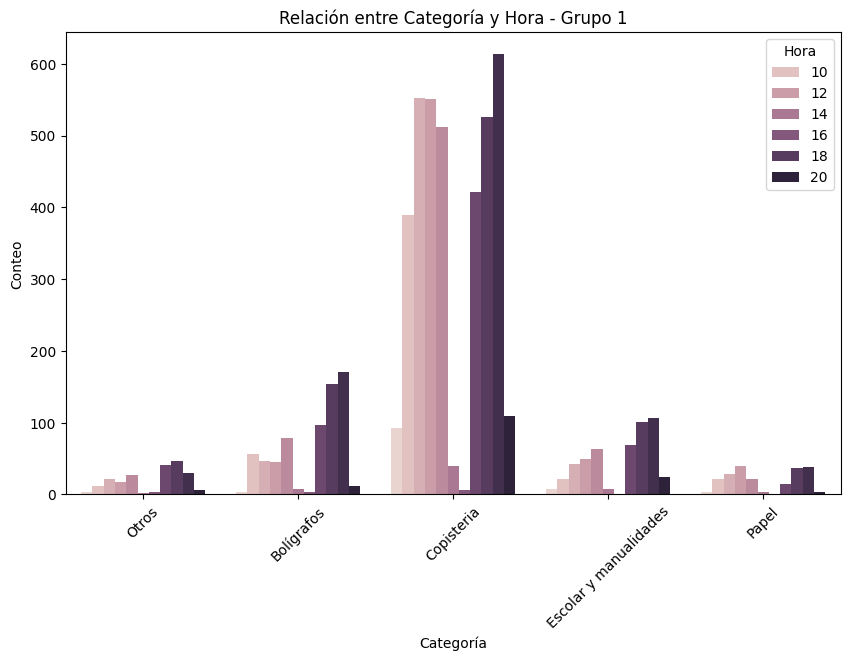

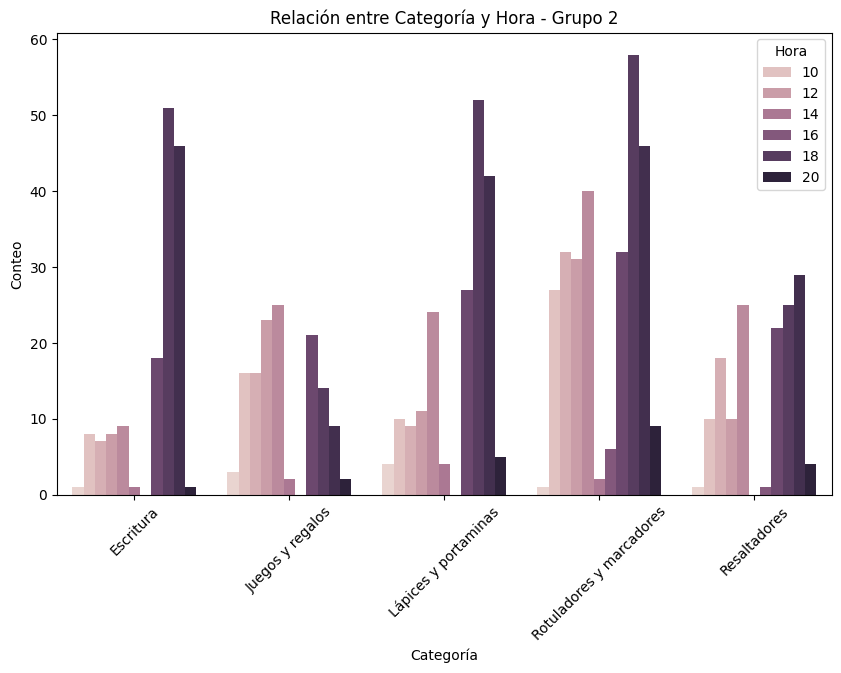

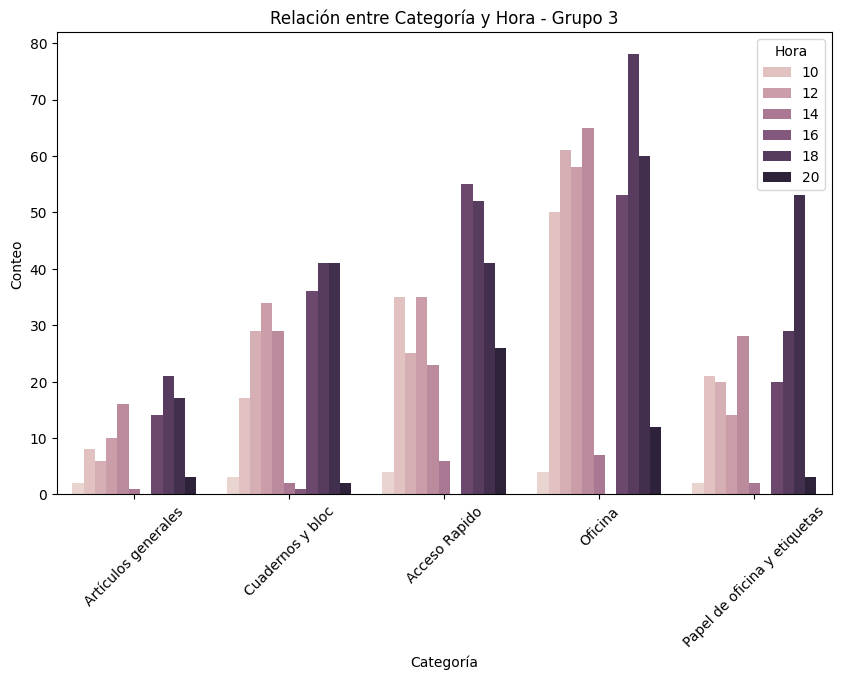

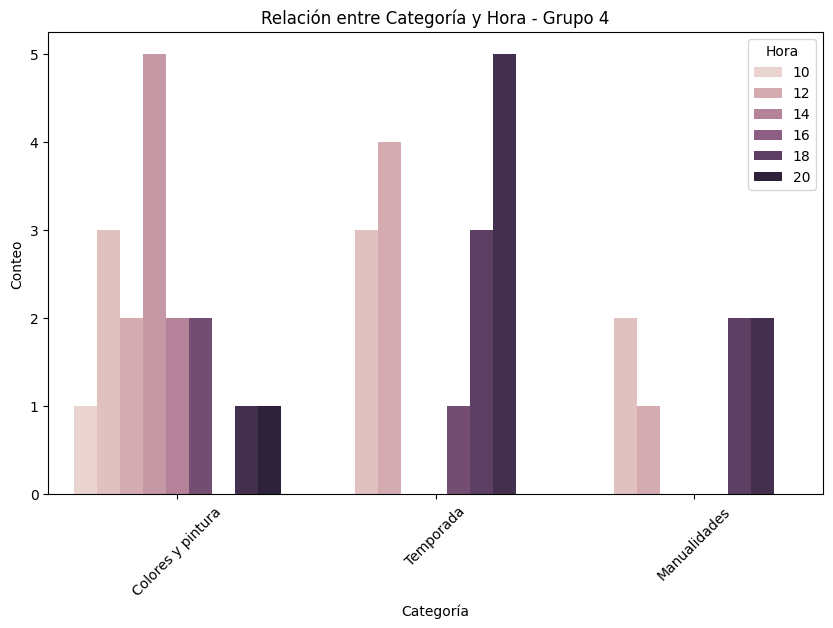

In [14]:
plot_categorical_relationship_fin(ventas, "Categoría","Hora")

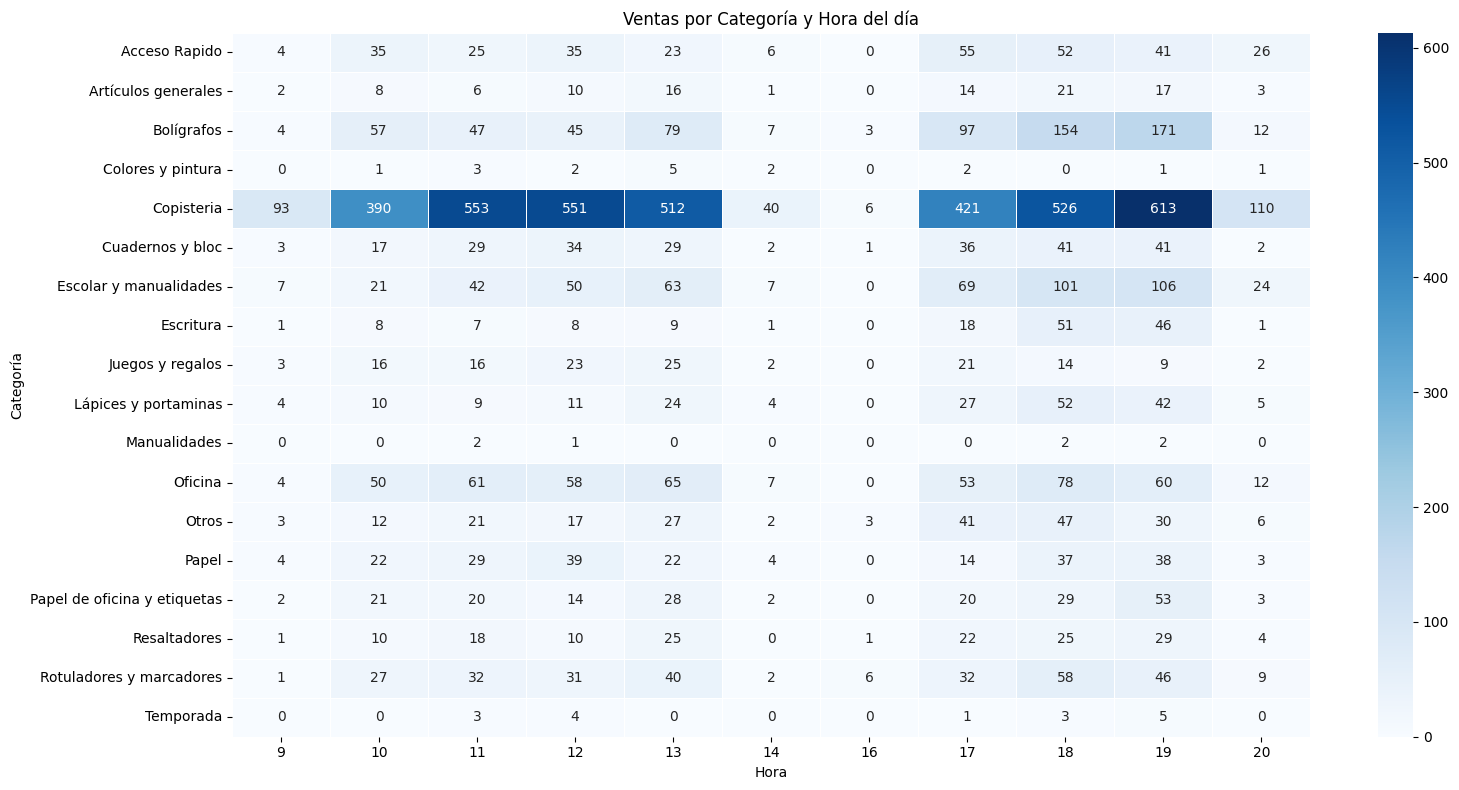

In [15]:
pivot = pd.crosstab(ventas['Categoría'], ventas['Hora'])

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt='d', linewidths=0.5)
plt.title('Ventas por Categoría y Hora del día')
plt.xlabel('Hora')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import chi2_contingency

chi2, p_valor, gl, esperados = chi2_contingency(pivot)
print(f'P-valor: {p_valor:2f}')

if p_valor < 0.05:
    print('✅ Sí hay relación significativa entre categoría y hora')
else:
    print('❌ No hay relación significativa')

P-valor: 0.000000
✅ Sí hay relación significativa entre categoría y hora


In [17]:
n = pivot.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(pivot.shape) - 1)))
print(f'Cramér\'s V: {cramers_v:.3f}')

Cramér's V: 0.087


In [18]:
ventas.groupby('Categoría')['Hora'].agg(lambda x: x.value_counts().idxmax()).reset_index().rename(columns={'Hora': 'Hora pico'})

,Categoría,Hora pico
0,Acceso Rapido,17
1,Artículos generales,18
2,Bolígrafos,19
3,Colores y pintura,13
4,Copisteria,19
5,Cuadernos y bloc,19
6,Escolar y manualidades,19
7,Escritura,18
8,Juegos y regalos,13
9,Lápices y portaminas,18


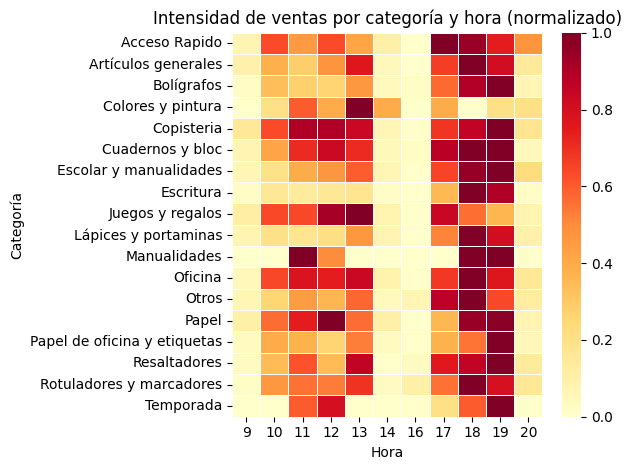

In [19]:
pivot_norm2 = pivot.div(pivot.max(axis=1), axis=0)

sns.heatmap(pivot_norm2, cmap='YlOrRd', linewidths=0.5)
plt.title('Intensidad de ventas por categoría y hora (normalizado)')
plt.tight_layout()
plt.show()

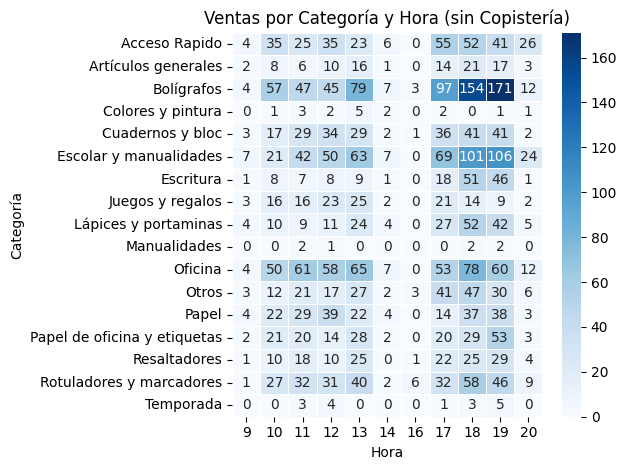

In [20]:
pivot_sin_copia = pivot[~pivot.index.str.contains('Copisteria|Copistería')]

sns.heatmap(pivot_sin_copia, cmap='Blues', annot=True, fmt='d', linewidths=0.5)
plt.title('Ventas por Categoría y Hora (sin Copistería)')
plt.tight_layout()
plt.show()

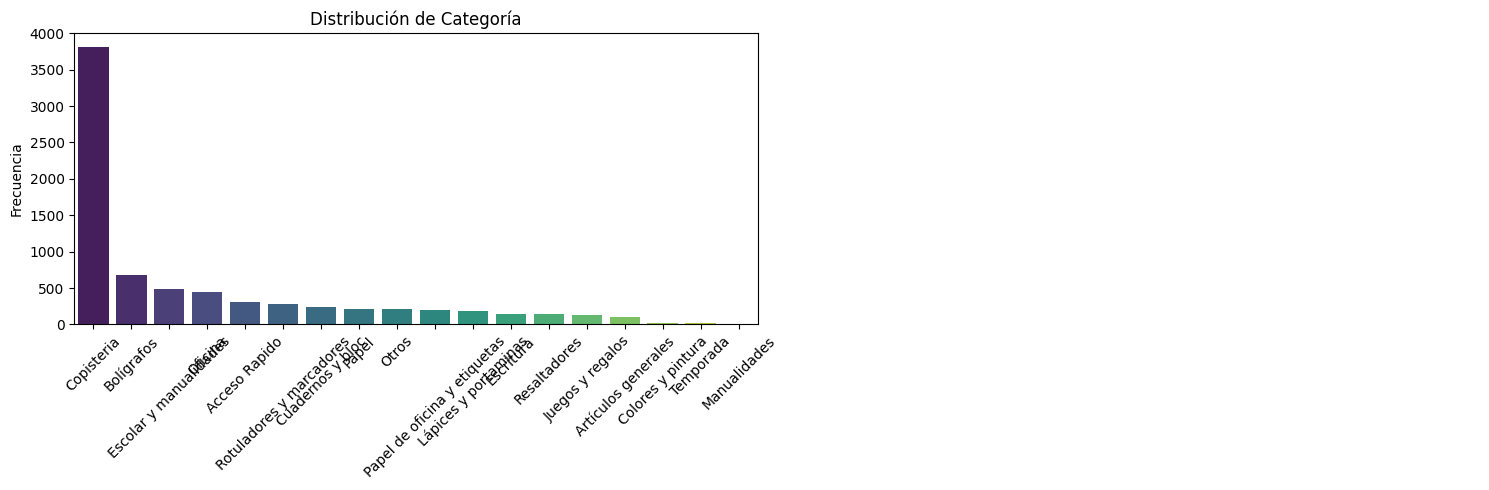

In [25]:
pinta_distribucion_categoricas(ventas, ['Categoría'])

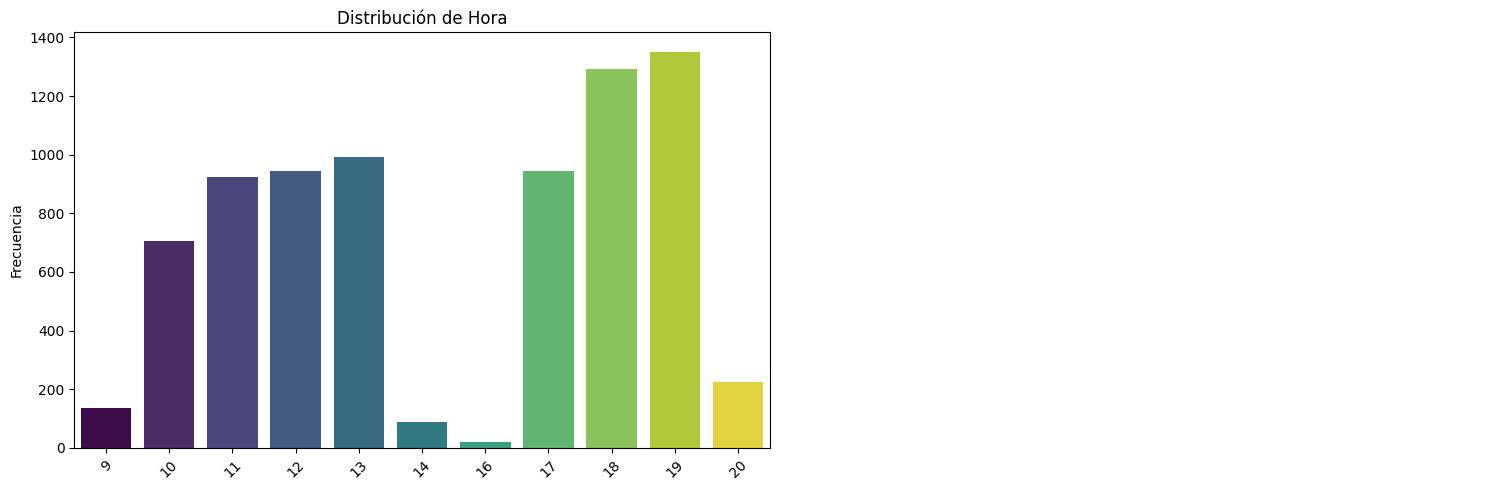

In [27]:
pinta_distribucion_categoricas(ventas, ["Hora"])

## Conclusiones: Categoría × Hora

### Estadísticas
- La relación entre categoría y hora existe pero es muy débil (Cramér's V = 0.087). La hora del día no determina qué categoría se compra.

### Comportamiento general
- Todas las categorías siguen el mismo patrón bimodal: mañana (10-13h) y tarde (17-19h). El negocio tiene dos picos claros independientemente de lo que se compre.

### Por categoría
- **Bolígrafos y Escolar** se compran más por la tarde, posiblemente estudiantes que vienen después del colegio.
- **Oficina** es más de mañana, posiblemente trabajadores que pasan antes o durante su jornada.
- **Manualidades** tiene volumen tan bajo que no hay patrón claro.

### Implicaciones para el negocio
- No tiene sentido hacer promociones por categoría según la hora porque el comportamiento es demasiado uniforme.
- Sí tendría sentido reforzar el personal en los picos de 12h y 19h, que son las horas más activas para casi todas las categorías.
- El hueco de 14-16h es una oportunidad: si hay demanda perdida en ese horario, abrir podría incrementar ventas especialmente en Oficina.